<a href="https://colab.research.google.com/github/hieuvu-0111/Deep-Learning-with-AlexNet-and-CIFAR-10/blob/main/Deep_Learning_Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep learning with AlexNet and CIFAR10

This notebook is adapted from a Deep Learning course assignment, with the aim of familiarizing students with training and testing the AlexNet neural network for an image classification task. The tasks include the process of loading data, preprocessing images, building the AlexNet model, evaluating its performance, and discussing some relevant questions. Below is the structure of the notebook:

1.  **Coding tasks:**

    1.1 Load the dataset and perform image preprocessing, then split the data into training, validation, and test sets to prepare it for model training and evaluation.  

    1.2 Implement the vanilla AlexNet architecture from scratch, referred to as AlexNet version 1, by explicitly defining each layer in sequence for the image classification task.

    1.3 Evaluate the performance of AlexNet version 1 using appropriate evaluation metrics and report the results.  
    1.4 Develop an enhanced model, AlexNet version 2, by adding or modifying architectural components with the goal of improving performance over AlexNet version 1. Clearly describe the design choices made.  

    1.5  Evaluate the performance of AlexNet version 2 and compare it with AlexNet version 1. Provide clear observations and analysis on how the architectural enhancements affected model effectiveness.  

2.  **Open discussion questions:**

    2.1 Preprocessing choices implicitly define the input distribution seen by the model. Select one preprocessing step you applied (for example normalization scheme, resizing method, or color space handling) and explain how it changes the geometry of the optimization landscape and the types of features the network can learn. Why might a different choice lead to slower convergence or worse generalization?  

    2.2 AlexNet contains multiple design elements such as large early kernels, aggressive downsampling, and deep fully connected layers. Based on your implementation and results, which of these elements do you believe are essential for AlexNet performance on your dataset, and which ones are largely incidental? Defend your answer using both intuition and experimental evidence.  

    2.3 When you modified AlexNet version 1 to obtain AlexNet version 2, how can you distinguish a genuine architectural improvement from a performance gain caused by randomness, training dynamics, or favorable initialization? Describe specific experimental controls or validation strategies that would support your conclusion.  
    2.4 Beyond reporting a higher accuracy, how would you diagnose where AlexNet version 2 improves over version 1 and where it still fails? Discuss how error analysis techniques such as confusion matrices, per class metrics, or misclassified example inspection can reveal strengths and weaknesses of the model.  

    2.5 Modern models are often built on large pretrained backbones, meaning networks that have already been trained on massive datasets such as ImageNet and are then adapted to new tasks using transfer learning. In this context, what important insights do you gain by training AlexNet entirely from random initialization, without any pretrained weights, that might be hidden or overlooked when starting from a pretrained model?  

The dataset we will be working on is CIFAR10 dataset. CIFAR10 (https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60,000 32x32 colour images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images. Here follow the ten object classes:
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

Here follows some data samples in the dataset:

![alt text](https://docs.pytorch.org/tutorials/_images/cifar10.png)

### Reference {-}:
Alex Krizhevsky, Ilya Sutskever, Geoffrey E. Hinton, "Imagenet classification with deep convolutional neural networks", NIPS'12. Link to the paper: https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf



In [ ]:
# Import libraries
import numpy as np
import tensorflow as tf
import keras              # Keras is the high-level API of TensorFlow

In [ ]:
# Load the cifar10 dataset and split train/test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Train shape: X_train = " + str(X_train.shape) + ", y_train = " + str(y_train.shape))
print("Test shape: X_test = " + str(X_test.shape) + ", y_test = " + str(y_test.shape))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train shape: X_train = (50000, 32, 32, 3), y_train = (50000, 1)
Test shape: X_test = (10000, 32, 32, 3), y_test = (10000, 1)


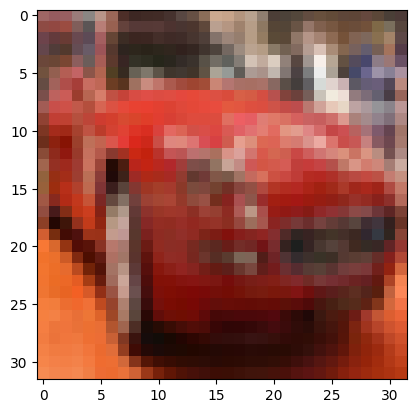

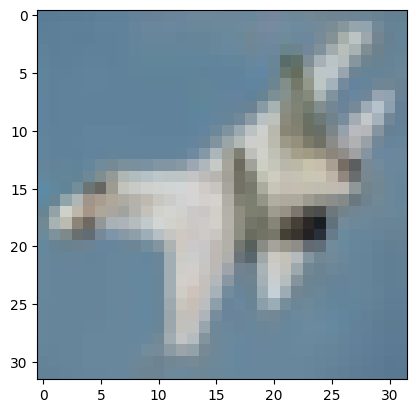

In [ ]:
# Show some samples in the dataset
import matplotlib.pyplot as plt
imgplot = plt.imshow(X_train[5])
plt.show()
imgplot = plt.imshow(X_test[10])
plt.show()

In [ ]:
# Normalize pixel values
X_train, X_test = X_train/255.0, X_test/255.0

## 1. Coding tasks

### 1.1 *(1 point)* Load the dataset (done) and perform image preprocessing (done), then split the data into training, validation, and test sets to prepare it for model training and evaluation.  


In [ ]:
# Split train/valid from the training set
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=5)

print("Train shape: X_train = " + str(X_train.shape) + ", y_train = " + str(y_train.shape))
print("Val shape: X_val = " + str(X_val.shape) + ", y_val = " + str(y_val.shape))
print("Test shape: X_test = " + str(X_test.shape) + ", y_test = " + str(y_test.shape))

Train shape: X_train = (45000, 32, 32, 3), y_train = (45000, 1)
Val shape: X_val = (5000, 32, 32, 3), y_val = (5000, 1)
Test shape: X_test = (10000, 32, 32, 3), y_test = (10000, 1)


### 1.2 *(1 point)* Implement the vanilla AlexNet architecture from scratch, referred to as AlexNet version 1, by explicitly defining each layer in sequence for the image classification task. Since AlexNet was not originally designed for the assignment dataset (i.e., CIFAR 10), you will need to make appropriate modifications to adapt the model, such as adjusting the input dimensions and the output layer.

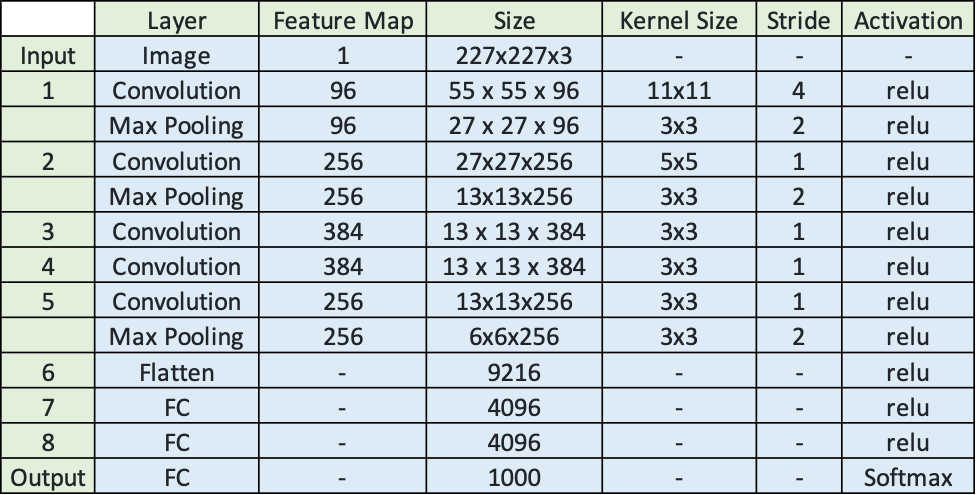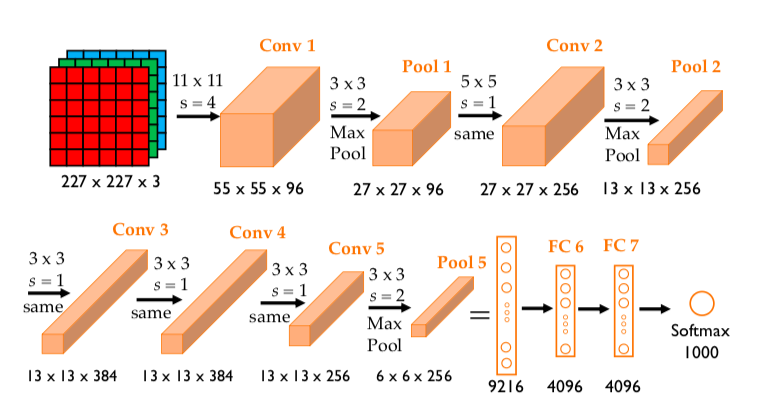

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define AlexNet Version 1
def build_alexnet_v1(input_shape, num_classes):
    model = Sequential([
        # 1st Convolutional Layer
        # Adapting to a 5x5 kernel with stride 1
        Conv2D(filters=96, kernel_size=(5, 5), strides=(1,1), activation='relu',
               input_shape=input_shape, padding='valid'),

        # Max Pooling
        MaxPooling2D(pool_size=(3, 3), strides=(2,2), padding='valid'),

        # 2nd Convolutional Layer
        Conv2D(filters=256, kernel_size=(5, 5), strides=(1,1), activation='relu',
               padding='same'),

        # Max pooling
        MaxPooling2D(pool_size=(3, 3), strides=(2,2), padding='valid'),

        # 3rd Convolutional Layer
        Conv2D(filters=384, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same'),

        # 4th Convolutional Layer
        Conv2D(filters=384, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same'),

        # 5th Convolutional Layer
        Conv2D(filters=256, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same'),

        # Max pooling
        MaxPooling2D(pool_size=(3, 3), strides=(2,2), padding='valid'),

        # Flatten
        Flatten(),

        # 1st Fully Connected Layer
        Dense(units=4096, activation='relu'),

        # 2nd Fully Connected Layer
        Dense(units=4096, activation='relu'),

        # Output Layer
        # Modify to 10 units
        Dense(units=num_classes, activation='softmax')
    ])
    return model

# Input shape for CIFAR-10 is (32, 32, 3)
input_shape = (32, 32, 3)
# Number of classes for CIFAR-10 is 10
num_classes = 10

# Build the model
alexnet_v1 = build_alexnet_v1(input_shape, num_classes)

alexnet_v1.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 28, 28, 96)     │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 13, 13, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 13, 13, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,740,234 (94.38 MB)

 Trainable params: 24,740,234 (94.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
alexnet_v1.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

In [ ]:
epochs = 50
batch_size = 256

# Create a callback ModelCheckpoint. This callback will save the model when finding one better than the current best.
mc = tf.keras.callbacks.ModelCheckpoint(filepath="best_model_v1.keras", # Path to save the model
                                     monitor='val_loss', # Metric to evaluate the model performance when looking for a better model.
                                     mode='min', # mode='auto'/'max'/'min': the monitor should be max/min to be better.
                                                 # In auto mode, the mode is set to max if the quantities monitored are 'acc' or start with 'fmeasure' (f-score) and are set to min for the rest of the quantities.
                                     verbose=0, # Inform every time a better model is found and saved.
                                     save_best_only=True) # Only save the model if the current training epoch is the best. 'False' means save models of all training epochs

history_v1 = alexnet_v1.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[mc])

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - accuracy: 0.1635 - loss: 2.1722 - val_accuracy: 0.3222 - val_loss: 1.7444
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.4159 - loss: 1.5304 - val_accuracy: 0.5396 - val_loss: 1.2504
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.5730 - loss: 1.1722 - val_accuracy: 0.5908 - val_loss: 1.1401
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.6507 - loss: 0.9821 - val_accuracy: 0.6386 - val_loss: 1.0230
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.7119 - loss: 0.8226 - val_accuracy: 0.6728 - val_loss: 0.9401
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.7429 - loss: 0.7285 - val_accuracy: 0.6888 - val_loss: 0.9071
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.7804 - loss: 0.6336 - val_accuracy: 0.7038 - val_loss: 0.8753
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.8148 - loss: 0.5283 


### 1.3 *(1 point)* Evaluate the performance of AlexNet version 1 using appropriate evaluation metrics and report the results.  


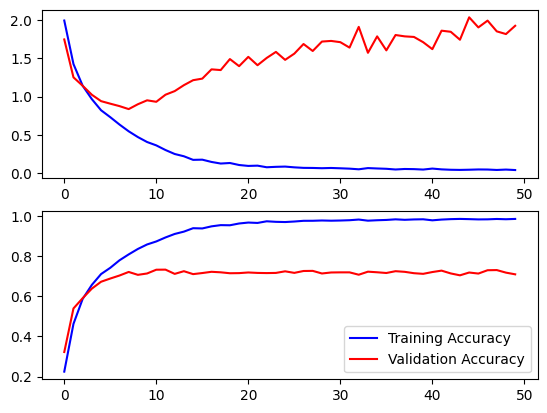

In [ ]:
# Visualize training and validation performance
f,ax=plt.subplots(2,1)

# Plot training and validation loss
ax[0].plot(history_v1.history['loss'], color='b',label='Training Loss')
ax[0].plot(history_v1.history['val_loss'],color='r',label='Validation Loss')

# Plot training and validation accuracy
ax[1].plot(history_v1.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history_v1.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()

In [ ]:
# Let us load a saved model and evaluate its performance on the test set
model = tf.keras.models.load_model("best_model_v1.keras")
result = alexnet_v1.evaluate(X_test, y_test) # If unspecified, batch_size will default to 32

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7304 - loss: 1.7927


In [ ]:
# Show the model performance
print(alexnet_v1.metrics_names) # result[0] is loss, result[1] is accuracy. The metrics are defined in LeNet.complie(...)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result[0],result[1]))

['loss', 'compile_metrics']
Loss and accuracy on the test set: loss = 1.3524419069290161, accuracy = 0.7152000069618225


### Discussion on AlexNet version 1:

We have trained an AlexNet architecture adapted only on the CIFAR‑10 input size (32×32×3) and 10 output classes. Based on the graph and the metric, we can see that the model perform pretty well with the accuracy on the test set of 0.715. However, it is a clear pattern that the difference between accuracy in the training set and the test set is mostly larger than 20%, implying that the model is clearly overfitted.

Perhaps the original AlexNet architecture is oversized and too complicated for training on small images like CIFA10. Also, it did not have sufficient regularization and dropout, as well other architectural adjustments to prevent overfitting.

Since we notice that version 1 is not optimized for our dataset, we are going to conduct some architectural adjustments and enhancements in the next version.

### 1.4 *(1 point)* Develop an enhanced model, AlexNet version 2, by adding or modifying architectural components with the goal of improving performance over AlexNet version 1. Clearly describe the design choices made.  


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import RandomFlip, RandomRotation

# Define AlexNet version 2
def build_alexnet_v22(input_shape, num_classes):
    model = Sequential([

        # Data Augmentation Layers
        RandomFlip("horizontal", input_shape=input_shape),
        RandomRotation(0.1),

        # 1st Convolutional layer
        # Adapting to a 5x5 kernel with stride 1
        # Add L2 regularization and Batch normalization
        Conv2D(filters=96, kernel_size=(5, 5), strides=(1,1), activation='relu',
               input_shape=input_shape, padding='valid', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # Use 2x2 kernel size instead
        MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding='valid'),

        # 2nd Convolutional Layer
        # Add L2 regularization and Batch normalization
        Conv2D(filters=256, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # Use 2x2 kernel size instead
        MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding='valid'),

        # 3rd Convolutional Layer
        # Add L2 regularization and Batch normalization
        Conv2D(filters=384, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # 4th Convolutional Layer
        # Add L2 regularization and Batch normalization
        Conv2D(filters=384, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # 5th Convolutional Layer
        # Add L2 regularization and Batch normalization
        Conv2D(filters=256, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # Use 2x2 kernel size instead
        MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding='valid'),

        # Flatten
        Flatten(),

        # 1st Fully Connected Layer
        # Add L2 regularization and drop out
        Dense(units=4096, activation='relu', kernel_regularizer=l2(0.005)),
        Dropout(0.5),

        # 2nd Fully Connected Layer
        # Add L2 regularization and drop out
        Dense(units=4096, activation='relu', kernel_regularizer=l2(0.005)),
        Dropout(0.5),

        # Output Layer
        Dense(units=num_classes, activation='softmax', kernel_regularizer=l2(0.005))
    ])
    return model

# Input shape
input_shape = (32, 32, 3)
# Number of classes for CIFAR-10 is 10
num_classes = 10

# Build the model
alexnet_v22 = build_alexnet_v2(input_shape, num_classes)

alexnet_v22.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 28, 28, 96)     │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 28, 28, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 14, 14, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,752,010 (25.76 MB)

 Trainable params: 6,749,258 (25.75 MB)

 Non-trainable params: 2,752 (10.75 KB)

### Summary of AlexNet Version 2 adjustments:

- Data Augmentation: at the beginning of the network, we added a data augmentation layer (RandomFlip and RandomRotation) to make small and realistic variations in the training images. This helps expand the effective size of the dataset, reduces overfitting, and improves the model’s robustness to minor changes in viewpoint or orientation.

- Max pooling kernel size from 3×3 to 2×2: A smaller size of kernel size preserves more spatial detail of the input, especially here when CIFAR‑10 images are low resolution, thus it can help the model retain useful features instead of downsampling too aggressively.

- L2 regularization (0.005) on all layers: Applying L2 regularization into both convolutional and fully connected layers helps control weight growth and reduces overfitting - one of the main issues in the first version.

- Batch normalization on all convolutional layers: Batch normalization can stabilize activation, improve gradient flow, and accelerate convergence. This makes the network easier to train and less sensitive to initialization.

- Dropout (0.5) and L2 regularization in fully connected layers: Since fully connected layers have numerous parameters, we combine dropout with L2 regularization in the effort of preventing memorization and incentivizing more robust and general feature learning.


In [ ]:
# Compile the model
alexnet_v22.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

In [ ]:
epochs = 50
batch_size = 256

# Create a callback ModelCheckpoint. This callback will save the model when finding one better than the current best.
mc = tf.keras.callbacks.ModelCheckpoint(filepath="best_model_v22.keras", # Path to save the model
                                     monitor='val_loss', # Metric to evaluate the model performance when looking for a better model.
                                     mode='min', # mode='auto'/'max'/'min': the monitor should be max/min to be better.
                                                 # In auto mode, the mode is set to max if the quantities monitored are 'acc' or start with 'fmeasure' (f-score) and are set to min for the rest of the quantities.
                                     verbose=0, # Inform every time a better model is found and saved.
                                     save_best_only=True) # Only save the model if the current training epoch is the best. 'False' means save models of all training epochs

history_v22 = alexnet_v22.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[mc])

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.3023 - loss: 15.5309 - val_accuracy: 0.1056 - val_loss: 6.0296
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.4967 - loss: 3.6365 - val_accuracy: 0.1506 - val_loss: 3.9486
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.5579 - loss: 2.0722 - val_accuracy: 0.3124 - val_loss: 2.9279
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.5853 - loss: 1.8209 - val_accuracy: 0.4752 - val_loss: 2.0891
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.6059 - loss: 1.7773 - val_accuracy: 0.4910 - val_loss: 2.2899
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.6208 - loss: 1.7846 - val_accuracy: 0.4708 - val_loss: 2.2109
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.6299 - loss: 1.7784 - val_accuracy: 0.4082 - val_loss: 2.6990
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.6484 - loss: 1.7471 -

### 1.5 *(1 point)* Evaluate the performance of AlexNet version 2 and compare it with AlexNet version 1. Provide clear observations and analysis on how the architectural enhancements affected model effectiveness.

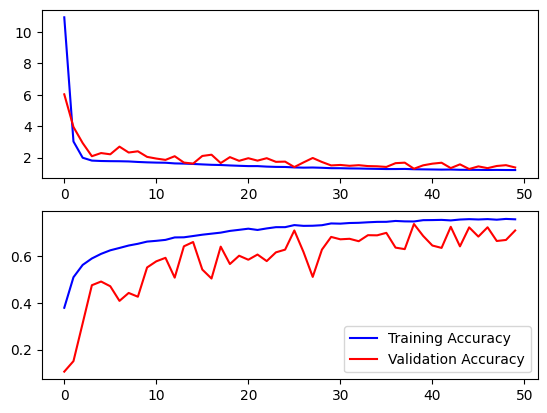

In [ ]:
# Visualize training and validation performance
f,ax=plt.subplots(2,1)

# Plot training and validation loss
ax[0].plot(history_v22.history['loss'], color='b',label='Training Loss')
ax[0].plot(history_v22.history['val_loss'],color='r',label='Validation Loss')

# Plot training and validation accuracy
ax[1].plot(history_v22.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history_v22.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()

In [ ]:
# Let us load a saved model and evaluate its performance on the test set
model = tf.keras.models.load_model("best_model_v22.keras")
result = alexnet_v22.evaluate(X_test, y_test) # If unspecified, batch_size will default to 32

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7198 - loss: 1.3450


In [ ]:
# Show the model performance
print(alexnet_v22.metrics_names) # result[0] is loss, result[1] is accuracy. The metrics are defined in LeNet.complie(...)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result[0],result[1]))

['loss', 'compile_metrics']
Loss and accuracy on the test set: loss = 1.3524419069290161, accuracy = 0.7152000069618225


### Comparison

In version 2, we can see clear improvements in generalization and training stability. While version 1 showed heavy overfitting and a large gap between training and validation accuracy, version 2 demonstrates more balanced and controlled learning behavio. The difference between accuracy of training and validating accuracy is now about 5% only, with the loss 1.35244 and accuracy of 0.7152 in the test set, which is mostly similar to the result of the version.

Also, validation loss decreases more consistently and validation accuracy increases more clearly across epoches, which is a better behavior. These things altogether suggest that we have controlled overfitting better.

### Analysis of enhancements

- We added a data augmentation layer (RandomFlip and RandomRotation) to create some variations in the training images. This helps the model learning more general and reduces overfitting when inputs have minor changes in viewpoint or orientation.

- Batch Normalization on all convolutional layers stabilizes activations and gradients and makes optimization easier, so it leads to better convergence and more reliable validation accuracy. Indeed, we can see in version 2 a faster early rise in both train and validation accuracy and smoother loss descent.

- L2 regularization (0.005) on convolutional and fully connected layers has discouraged overly large patterns, thereby making model more general and simpler (reducing overfitting). Indeed, in version 2, validation loss is lower and the train–validation accuracy gap is smaller than those of version 1. *By trying different value of regularizing hyperparameters, we notice that this factor affects the level of overfitting most significantly.* Also, trying different hyperparameter values helps us determine which one is the most suitable and balanced to controll overfitting while keeping model's high accuracy.

- Dropout 0.5 on fully connected layers randomly deactivates neurons to help the model learn more generalizable features. In so doing, it reduces overfitting in the second version as we have seen.

- Max‑pool kernel size from 3×3 to 2×2 means a gentler downsampling, so it preserves spatial detail and improve bias feature learning in the images. It makes the accuracy increases steeper in validation test while maintaining efficiency.


## 2. Open discussion questions

### 2.1 *(1 point)* Preprocessing choices implicitly define the input distribution seen by the model. Select one preprocessing step you applied (for example normalization scheme, resizing method, or color space handling) and explain how it changes the geometry of the optimization landscape and the types of features the network can learn. Why might a different choice lead to slower convergence or worse generalization?  


A relevant preprocessing step we have done in this project is normalizing pixel values by dividing by 255. This reshapes the input distribution from the wide range [0,255] to [0,1]. With the smaller and consistent input magnitudes, gradients become more stable, thus helping the network converge faster and reducing the risk of exploding updates.

On the flip side, if pixels are not normalized and remain original range, the model receives inputs with very large magnitudes. This makes gradients unstable and slower, because now the optimizer have to take tiny steps.

Consider another impactful preprocessing choice, which is converting images to grayscale. This step reduces the input dimension from 3 channels to 1, making the feature space that the model have to learn simpler. Then, it can help the model more stable and reduce overfitting. However, it also removes color information that may be useful for distinguishing certain classes, so the downside may be about limiting the maximum performance of the model. *In fact, in the initial run of trying on turning input to grayscale, the model indeed had bad and unexpected learning behavior with training and validation accuracy mostly remain constant across epoches.*

If we choose other preprocessing operations, such as standardization, whitening, or different resizing methods, these techniques would similarly change the input distribution and could either help or hinder convergence (depending on how well they match the model and dataset).

### 2.2 *(1 point)* AlexNet contains multiple design elements such as large early kernels, aggressive downsampling, and deep fully connected layers. Based on your implementation and results, which of these elements do you believe are essential for AlexNet performance on your dataset, and which ones are largely incidental? Defend your answer using both intuition and experimental evidence.  


Based on what we have done in AlexNet version 1 and 2, we can assess the essentiality of its key design elements.

#### 1. Large early kernels

*   **Intuition:** Original AlexNet used a very large 11x11 kernel in its first layer to capture broad, low-level features from high-resolution ImageNet images. For smaller images like CIFAR-10 (32x32), such a large kernel can quickly reduce spatial information or capture too aggressive features, which can perhaps lose fine-grained details crucial for distinguishing small objects.

*   **Experimental Evidence:** In our Version 1, we adapted the kernel size to 5x5 for the first convolutional layer. While this is smaller than the original AlexNet's 11x11, it is still relatively large for a 32x32 input. Version 1, despite using this 5x5 kernel, overfitting is still clear. In Version 2, we kept the 5x5 kernel but added regularization and batch normalization. The improved performance of Version 2 suggests that the 5x5 kernel per se was not the primary cause of overfitting but rather the lack of other regularization techniques. For CIFAR-10, an even smaller kernel (e.g., 3x3) might be more optimal in the initial layers to preserve local details, but the 5x5 is effective when combined with strong regularization.

*   **Conclusion:** The idea of using larger kernels in early layers to learn general features is *essential*, but the specific size needs careful adaptation to the input resolution. For CIFAR-10, 5x5 (an adaptation from the original 11x11) can be effective (but smaller kernel sizes might be more naturally suited).

#### 2. Aggressive downsampling (e.g., maxPooling with large kernels/strides)

*   **Intuition:** Aggressive downsampling reduces the spatial dimensions of feature maps, which helps reduce computational load. However, for a low-resolution dataset like CIFAR-10, aggressive downsampling (e.g., 3x3 max-pooling with stride 2) can quickly remove the already limited spatial information, making it difficult for following layers to learn discriminative features. The objects in CIFAR-10 are often small and occupy a significant portion of the image, so losing too much detail too early can lead to significantly negative effect.

*   **Experimental Evidence:** AlexNet Version 1 used 3x3 max-pooling with stride 2. This likely contributed to the poor validation performance due to information loss. In Version 2, we reduced the max-pooling kernel size to 2x2. Then this change, was part of a set of enhancements, indeed significantly improved the model's generalization. This suggests that the *original aggressive downsampling* (3x3 pooling) is largely **incidental** for CIFAR-10, and a *gentler downsampling* (2x2 pooling for example) is more **essential** to preserve crucial spatial details.

*   **Conclusion:** Aggressive downsampling (as in the original AlexNet) is **incidental** for CIFAR-10. Milder downsampling is **essential** to retain spatial information while still achieving the same effect.

#### 3. Deep fully connected layers (e.g., two 4096-unit layers)

*   **Intuition:** Deep fully connected layers in AlexNet are responsible for high-level feature combination and final classification. The hugh number of parameters (two 4096-unit with millions of parameters) provides significant capacity for learning complex patterns. However, this high capacity also makes them extremely prone to overfitting, especially when the training dataset is relatively small (like CIFAR-10) and does not provide enough unique examples to constrain all these parameters.

*   **Experimental Evidence:** in version 2 we still used those 4096 units in training fully connected layers, but with the use of regularization, overfitting is then controlled while keeping the same accuracy of model.

*   **Conclusion:** The raw and deep fully connected layers without regularization are **incidental** as they lead to overfitting on CIFAR-10. However, *when regularized (with L2 and Dropout)*, these layers become **essential** for the model's performance by providing the capacity for complex decision-making.

To illustrate the idea of essential and incidental factors, especially about deep fully connected layers, we consider training model with smaller connecting units (1024) while remaining the same other adjustments as in version 2.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import RandomFlip, RandomRotation

# Define AlexNet version 2
def build_alexnet_v2(input_shape, num_classes):
    model = Sequential([

        # Data Augmentation Layers
        RandomFlip("horizontal", input_shape=input_shape),
        RandomRotation(0.1),

        # 1st Convolutional layer
        # Adapting to a 5x5 kernel with stride 1
        # Add L2 regularization and Batch normalization
        Conv2D(filters=96, kernel_size=(5, 5), strides=(1,1), activation='relu',
               input_shape=input_shape, padding='valid', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # Use 2x2 kernel size instead
        MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding='valid'),

        # 2nd Convolutional Layer
        # Add L2 regularization and Batch normalization
        Conv2D(filters=256, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # Use 2x2 kernel size instead
        MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding='valid'),

        # 3rd Convolutional Layer
        # Add L2 regularization and Batch normalization
        Conv2D(filters=384, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # 4th Convolutional Layer
        # Add L2 regularization and Batch normalization
        Conv2D(filters=384, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # 5th Convolutional Layer
        # Add L2 regularization and Batch normalization
        Conv2D(filters=256, kernel_size=(3, 3), strides=(1,1), activation='relu',
               padding='same', kernel_regularizer=l2(0.005)),
        BatchNormalization(),

        # Use 2x2 kernel size instead
        MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding='valid'),

        # Flatten
        Flatten(),

        # 1st Fully Connected Layer
        # Add L2 regularization and drop out
        Dense(units=1024, activation='relu', kernel_regularizer=l2(0.005)),
        Dropout(0.5),

        # 2nd Fully Connected Layer
        # Add L2 regularization and drop out
        Dense(units=1024, activation='relu', kernel_regularizer=l2(0.005)),
        Dropout(0.5),

        # Output Layer
        Dense(units=num_classes, activation='softmax', kernel_regularizer=l2(0.005))
    ])
    return model

# Input shape
input_shape = (32, 32, 3)
# Number of classes for CIFAR-10 is 10
num_classes = 10

# Build the model
alexnet_v2 = build_alexnet_v2(input_shape, num_classes)

alexnet_v2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_6 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_6               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 28, 28, 96)     │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 28, 28, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 14, 14, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,752,010 (25.76 MB)

 Trainable params: 6,749,258 (25.75 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
# Compile the model
alexnet_v2.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

In [ ]:
epochs = 50
batch_size = 256

# Create a callback ModelCheckpoint. This callback will save the model when finding one better than the current best.
mc = tf.keras.callbacks.ModelCheckpoint(filepath="best_model_v2.keras", # Path to save the model
                                     monitor='val_loss', # Metric to evaluate the model performance when looking for a better model.
                                     mode='min', # mode='auto'/'max'/'min': the monitor should be max/min to be better.
                                                 # In auto mode, the mode is set to max if the quantities monitored are 'acc' or start with 'fmeasure' (f-score) and are set to min for the rest of the quantities.
                                     verbose=0, # Inform every time a better model is found and saved.
                                     save_best_only=True) # Only save the model if the current training epoch is the best. 'False' means save models of all training epochs

history_v2 = alexnet_v2.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[mc])

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.2976 - loss: 15.7679 - val_accuracy: 0.1072 - val_loss: 6.0519
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.4788 - loss: 3.7752 - val_accuracy: 0.2124 - val_loss: 3.4538
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.5385 - loss: 2.1225 - val_accuracy: 0.2460 - val_loss: 3.0991
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.5786 - loss: 1.8318 - val_accuracy: 0.5170 - val_loss: 1.9955
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.6051 - loss: 1.7585 - val_accuracy: 0.4156 - val_loss: 2.2846
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.6150 - loss: 1.7579 - val_accuracy: 0.5244 - val_loss: 2.0241
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.6323 - loss: 1.7452 - val_accuracy: 0.5496 - val_loss: 1.9819
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.6444 - loss: 1.7382 -

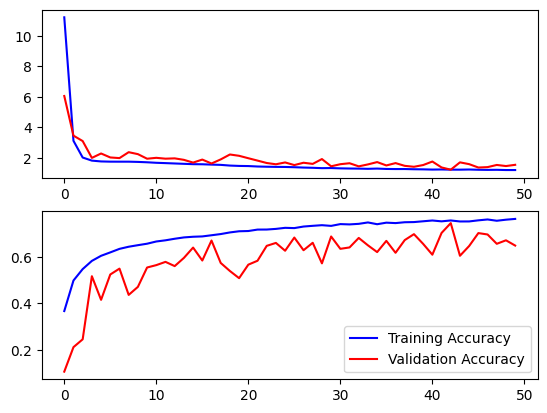

In [ ]:
# Visualize training and validation performance
f,ax=plt.subplots(2,1)

# Plot training and validation loss
ax[0].plot(history_v2.history['loss'], color='b',label='Training Loss')
ax[0].plot(history_v2.history['val_loss'],color='r',label='Validation Loss')

# Plot training and validation accuracy
ax[1].plot(history_v2.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history_v2.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()

In [ ]:
# Let us load a saved model and evaluate its performance on the test set
model = tf.keras.models.load_model("best_model_v2.keras")
result = alexnet_v2.evaluate(X_test, y_test) # If unspecified, batch_size will default to 32

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6624 - loss: 1.5010


In [ ]:
# Show the model performance
print(alexnet_v2.metrics_names) # result[0] is loss, result[1] is accuracy. The metrics are defined in LeNet.complie(...)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result[0],result[1]))

['loss', 'compile_metrics']
Loss and accuracy on the test set: loss = 1.5089648962020874, accuracy = 0.6567999720573425


Architecture of the above model has nothing different from the version 2 but the smaller dense layer units (1024 vs 4096 in the previous model). From the graph and the merics, it is clear that reducing connecting units reduce the accuracy of the model on the test set (from 71% to 66%), while the effect of reducing overfitting is still the same compared to the second vesion trained earlier. This supports the idea that raw and deep fully connected layers without regularization are incidental as they lead to overfitting, but with L2 and Dropout, these layers become essential for the model's performance. It also opens a question of balancing high accuracy with preventing overfitting.

### 2.3 *(1 point)* When you modified AlexNet version 1 to obtain AlexNet version 2, how can you distinguish a genuine architectural improvement from a performance gain caused by randomness, training dynamics, or favorable initialization? Describe specific experimental controls or validation strategies that would support your conclusion.  


To determine whether AlexNet V2 is genuinely better than V1, we can have some following approach:

- Multiple runs with different random states: We can run each model multiple times using different random seeds. For example, train the first version 3-5 times with different seeds, then train the second version 3-5 times with the same set of seeds, then compare the average accuracy of each model. It is expected that version 2 should consistently perform better than version 1 across most runs, not just once.

- Keep hyper parameters:  If version 1 and version 2 use different settings (learning rate, batch size, optimizer), then performance differences may come from training settings, not the architecture. Therefore, we should use the exact same training setup for both, such as optimizer, learning rate, batch size, and number of epochs, so that performance differences reflect architecture rather than training settings.

- Use a consistent train/validation split: A model might look better simply because it was trained on an “easy” split of the dataset. Therefore, using the same train–validation split for both models can avoid biased comparisons caused by differences in data partitioning. This ensures that both models are tested under the same conditions.

### 2.4 *(1 point)* Beyond reporting a higher accuracy, how would you diagnose where AlexNet version 2 improves over version 1 and where it still fails? Discuss how error analysis techniques such as confusion matrices, per class metrics, or misclassified example inspection can reveal strengths and weaknesses of the model.  


Higher overall accuracy of version 2 is a good indicator of improvement, but it alone does not tell the whole story. To truly understand where version 2 improves over Version 1 and where it still struggles, we need to delve into more detailed error analysis, for example, confusion matrices, per-class metrics, and misclassified example inspection.

#### 1. Confusion matrix

* A confusion matrix is a table that visualizes the performance of a classification model by dividing into four categories: true positive, true negative, false positive, and false negative. Then we can further calculate metrics like precision and recall.

- From confusion matrix, we can observe whether version 2 has reduced false positives or false negatives for certain classes compared to Version 1. We can pinpoint classes that are still frequently misclassified by Version 2, even if its overall accuracy is higher.

#### 2. Per-class metrics

- Instead of just overall accuracy, we can compute metrics like precision, recall, and F1-score for each individual class. Precision measures the proportion of true positive predictions among all positive predictions for a class. Recall measures the proportion of true positive predictions among all actual positive instances for a class.

- If Version 2 shows significantly higher precision and/or recall for a specific class compared to Version 1, it means the model is much better at identifying that class correctly without many false alarms (precision) or missing many instances (recall). Reversely, low precision, recall, or F1-score for particular classes in Version 2 would highlight its weaknesses.

#### 3. Misclassified example inspection

* This is a qualitative but highly informative technique. We would manually examine a subset of images that Version 1 classified correctly but Version 2 got wrong (if any), and more importantly, images that Version 1 got wrong but Version 2 got right, and images that *both* versions misclassified.

* By looking at examples that Version 2 correctly classified but Version 1 did not, we can understand what specific visual signals the new architecture (e.g., due to regularization or less aggressive pooling) learned to capture more effectively.

- Furthermore, inspecting images that Version 2 still misclassifies can reveal persistent challenges, for example, images that are genuinely hard to classify even for humans (e.g., blurred images, objects seen from unusual angles). Also, if Version 2 consistently misclassifies objects with certain background patterns or textures, it suggests that the model is still struggling to learn robust features independent of these confounding factors.


Here we analyze an example of using confusion matrix and per-class metrics in comparing performance of version 1 and version 2.

In [ ]:
# Import necessary libraries for evaluation
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Load AlexNet Version 1 and make predictions
alexnet_v1_model = tf.keras.models.load_model("best_model_v1.keras") # Load v1's best model
y_pred_v1 = alexnet_v1_model.predict(X_test)
y_pred_classes_v1 = np.argmax(y_pred_v1, axis=1)

# Load AlexNet Version 2 and make predictions
alexnet_v22_model = tf.keras.models.load_model("best_model_v22.keras") # Load v2's best model
y_pred_v22 = alexnet_v22_model.predict(X_test)
y_pred_classes_v22 = np.argmax(y_pred_v22, axis=1)

# Flatten y_test for use with sklearn metrics
y_true = y_test.flatten()

print("\n--- AlexNet Version 1 Evaluation ---")
print("Confusion Matrix (V1):")
print(confusion_matrix(y_true, y_pred_classes_v1))
print("\nClassification Report (V1):")
print(classification_report(y_true, y_pred_classes_v1, target_names=class_names))

print("\n--- AlexNet Version 2.2 Evaluation ---")
print("Confusion Matrix (V2):")
print(confusion_matrix(y_true, y_pred_classes_v22))
print("\nClassification Report (V2):")
print(classification_report(y_true, y_pred_classes_v22, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

--- AlexNet Version 1 Evaluation ---
Confusion Matrix (V1):
[[746  13  51  26  23   3  19   7  67  45]
 [ 11 812   7  12   2   4  22   3  23 104]
 [ 54   2 604  93  63  30 110  19  17   8]
 [ 10   2  66 661  44  73 100  19   9  16]
 [ 16   0  73  78 661  10  97  51  13   1]
 [ 10   1  55 293  39 491  51  43   4  13]
 [  2   1  33  46   9   4 887   4   8   6]
 [ 19   2  27  86  64  26  23 739   1  13]
 [ 46  21   9  18   9   3   9   1 862  22]
 [ 25  49   6  29   4   2  20  10  23 832]]

Classification Report (V1):
              precision    recall  f1-score   support

    airplane       0.79      0.75      0.77      1000
  automobile       0.90      0.81      0.85      1000
        bird       0.65      0.60      0.63      1000
         cat       0.49      0.66      0.56      1000
        deer       0.72      0.66      0.69      1000
         dog       0.76      0.49      0.60      1000
        frog      

As we may see, both AlexNet Version 1 and Version 2 achieved a very similar overall accuracy of approximately 72% on the test set. However, a deeper look at the per-class metrics can reveal different strengths and weaknesses of these two models.

- We can compare two versions' performance in each class. For example, airplane (Class 0), Version 2 shows a significant improvement in recall for 'airplane' (0.94 in version 2 vs 0.75 in version 1). This means version 2 is much better at identifying actual airplanes, making fewer false negatives for this class.

- However, AlexNet version 2 still struggles or performs worse in some specific cases. For instance, in ship (Class 8), while Version 1 had a high recall of 0.86 for 'ship', Version 2's recall drops significantly to 0.61. This means thi version is missing many actual ships, frequently misclassifying them as 'airplane' (320 instances in version 2 vs 46 in version 1's confusion matrix).

We can easily realize other insights related to other classes when analyzing these metrics.

Therefore, while overall accuracy might be similar, the whole story is not told completely without looking at these detailed metrics. As an example, the second version has become significantly better at identifying some classes while still struggling with other classes.

### 2.5 *(1 point)* Modern models are often built on large pretrained backbones, meaning networks that have already been trained on massive datasets such as ImageNet and are then adapted to new tasks using transfer learning. In this context, what important insights do you gain by training AlexNet entirely from random initialization, without any pretrained weights, that might be hidden or overlooked when starting from a pretrained model?  

Transfer learning is a technique that reuses a pre-trained model (trained on a large dataset) as a starting point for a new, related task. In so doing, it significantly reduces training time, computational costs, and the need for large labeled datasets.

However, training AlexNet entirely from random initialization, without any pretrained weights, offers several crucial insights that might be hidden or overlooked when starting from a pretrained model (transfer learning).

- Architectural learning ability:
Training from scratch shows how well the architecture of Alexnet itself can learn meaningful features without relying on large pretrained backbones, for example, ImageNet. This helps us assess whether its design is genuinely suitable for the target dataset.

- Sensitivity to hyperparameters:
Without pretrained process, the model becomes much more sensitive to initialization, learning rate, optimizer choice, batch size, and regularization. On the other hand, pretraining provides a very good initialization point. This makes the fine-tuning process much more stable and less prone to divergence.

- Insights for dataset limitations:
Because the model must learn all features from the dataset alone, issues such as insufficient data, label noise, or class similarity become more visible. Whereas transfer learning is incredibly data-efficient because it leverages knowledge from large source datasets. This can make a small or challenging dataset appear easier than it truly is, as the model is not learning all features from scratch.

- Reflect true optimization landscape:
From‑scratch, training reveals saddle points and unstable regions of the loss surface. However, pretrained models start closer to good minima, so it makes the optimization path appear "artificially" smooth.

- Measure the value of transfer learning:
We can directly compare a model trained from scratch with one using transfer learning, then we can gain a clear quantitative understanding about how much transfer learning improves accuracy, convergence speed, and stability for the specific task.